# How exoplanet discovery methods changed with time

**Date:** 2026-07-31  
**Scientific question:** How did the archive share of major discovery methods change between early and recent discoveries?  
**Preserved source:** `../2026-07-31-hot-jupiter-tidal-circularisation/giant_planet_archive_query.csv`

The archive records discovery year and method for confirmed planets. We compare
      broad time bins and quantify the change in the leading method. These are catalogue
      counts, not occurrence rates: telescope lifetimes, target selection, follow-up, and
      confirmation policy all shape the timeline. The result is useful as a history of the
      observed sample rather than a statement about the Galaxy's underlying planets.

      Data documentation: NASA Exoplanet Archive Planetary Systems table definitions and
      TAP guide. The composite-style table is convenient for population summaries but can
      combine parameters from different references, so only discovery metadata are used.

## Analysis contract

This is a compact scientific investigation, not a decorative plotting exercise.
The input is a preserved subset of a public astronomical archive. The notebook
records the upstream table or product, explains every quality cut, prints the
sample size after filtering, reports a numerical result with uncertainty, and
changes at least one defensible analysis choice to test robustness.

Archive catalogue values are heterogeneous measurements collected from the
literature or survey pipelines. A trend in this notebook is therefore a trend
in the selected archive sample, not automatically an occurrence rate, causal
relation, or complete census of nature. Display images are treated as image
arrays rather than calibrated photometry. Spectral equivalent widths identify
relative line strength but do not become elemental abundances without an
atmosphere model.

The small CSV or image already stored in this repository is used so the checked
notebook can be rerun offline. Its provenance remains the original archive; the
local copy is not a new survey release. Random resampling uses a fixed seed so
the uncertainty check is repeatable.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

RNG = np.random.default_rng(1999)
plt.style.use("seaborn-v0_8-whitegrid")
COLORS = {"navy":"#071426", "blue":"#1797c9", "cyan":"#2fc6b4",
          "gold":"#f4b942", "orange":"#ef6a45", "rose":"#ce4f78"}

In [2]:
data = pd.read_csv("../2026-07-31-hot-jupiter-tidal-circularisation/giant_planet_archive_query.csv").drop_duplicates("pl_name")
sample = data.dropna(subset=["disc_year", "discoverymethod"]).copy()
sample["disc_year"] = sample.disc_year.astype(int)
sample = sample[sample.disc_year.between(1990, 2026)]
print(f"Unique planets with year and method: {len(sample):,}")
print(sample.discoverymethod.value_counts().head(8))

Unique planets with year and method: 5,233
discoverymethod
Transit                      4027
Radial Velocity              1119
Transit Timing Variations      38
Imaging                        18
Eclipse Timing Variations      14
Astrometry                      6
Pulsar Timing                   5
Microlensing                    3
Name: count, dtype: int64


In [3]:
top = sample.discoverymethod.value_counts().head(5).index
sample["method_group"] = sample.discoverymethod.where(sample.discoverymethod.isin(top), "Other")
bins = [1989, 2005, 2010, 2015, 2020, 2026]
labels = ["1990–05", "2006–10", "2011–15", "2016–20", "2021–26"]
sample["era"] = pd.cut(sample.disc_year, bins=bins, labels=labels)
counts = pd.crosstab(sample.era, sample.method_group)
fractions = counts.div(counts.sum(axis=1), axis=0)
early = sample[sample.disc_year <= 2010].discoverymethod.value_counts(normalize=True)
recent = sample[sample.disc_year >= 2021].discoverymethod.value_counts(normalize=True)
lead_recent = recent.index[0]; lead_share = float(recent.iloc[0])
print(f"Recent leading method: {lead_recent} ({lead_share:.1%})")
print(fractions.round(3))

Recent leading method: Transit (72.4%)
method_group  Eclipse Timing Variations  ...  Transit Timing Variations
era                                      ...                           
1990–05                           0.000  ...                      0.000
2006–10                           0.010  ...                      0.000
2011–15                           0.004  ...                      0.011
2016–20                           0.001  ...                      0.002
2021–26                           0.002  ...                      0.013

[5 rows x 6 columns]


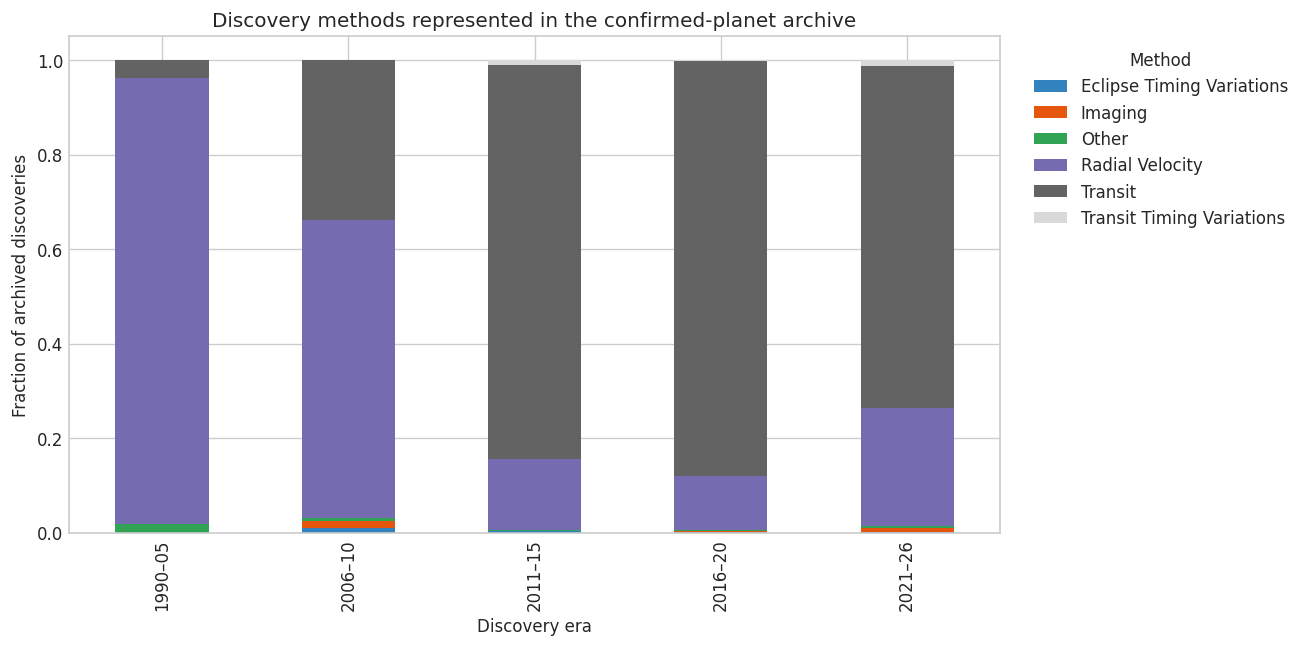

In [4]:
ax = fractions.plot(kind="bar", stacked=True, figsize=(11,5.5), colormap="tab20c")
ax.set(xlabel="Discovery era", ylabel="Fraction of archived discoveries",
       title="Discovery methods represented in the confirmed-planet archive")
ax.legend(title="Method", bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout(); plt.savefig("discovery_method_timeline.png", dpi=180); plt.show()

In [5]:
# Stress test: move the recent boundary from 2021 to 2019.
recent_alt = sample[sample.disc_year >= 2019].discoverymethod.value_counts(normalize=True)
alt_method, alt_share = recent_alt.index[0], float(recent_alt.iloc[0])
stable = alt_method == lead_recent
print(f"Boundary ≥2019: {alt_method} at {alt_share:.1%}; same leader={stable}")

Boundary ≥2019: Transit at 71.6%; same leader=True


In [6]:
result = {"id":"2026-07-31-exoplanet-discovery-method-timeline","title":"Exoplanet discovery methods through time","archive":"NASA Exoplanet Archive","date":"2026-07-31","question":"How has the discovery-method mix changed?","sample_size":int(len(sample)),"results":[f"{len(sample):,} unique planets with method and year",f"{lead_recent} contributes {lead_share:.1%} of 2021–26 entries",f"same leading method with a 2019 boundary: {stable}"],"validation":"The leading method is re-evaluated after shifting the recent-era boundary by two years.","notebook":"exoplanet-archive/2026-07-31-exoplanet-discovery-method-timeline/notebook.ipynb","hero":"exoplanet-archive/2026-07-31-exoplanet-discovery-method-timeline/discovery_method_timeline.png","tags":["exoplanets","discovery history","selection effects"]}
Path("result.json").write_text(json.dumps(result,indent=2)); print(result["results"])

['5,233 unique planets with method and year', 'Transit contributes 72.4% of 2021–26 entries', 'same leading method with a 2019 boundary: True']


## Reading the result responsibly

The primary number answers the stated question only for the documented sample
and method. The stress test asks whether a reasonable threshold change reverses
the conclusion. Agreement does not remove shared selection effects, calibration
limits, unresolved multiplicity, or missing catalogue fields. Disagreement is
reported rather than hidden. A publishable follow-up would repeat the query
against a pinned archive release, model the survey selection function, and use
the original calibrated products where available.

The notebook deliberately separates observation, calculation, interpretation,
and limitation. That makes it useful as a learning record and makes each claim
easy for another reader to audit.

Numerical precision in the printed summary follows the scale supported by this
exercise; extra decimal places would not create extra physical accuracy. The
saved figure exposes the distribution behind the headline value, while the
machine-readable result file lets the dashboard report the finding without
scraping prose. Readers should inspect the executed cells before reusing any
number in a wider scientific argument.

## Sources and comparison literature

- NASA Exoplanet Archive, TAP guide: https://exoplanetarchive.ipac.caltech.edu/docs/TAP/usingTAP.html
- Planetary Systems table definitions: https://exoplanetarchive.ipac.caltech.edu/docs/API_PS_columns.html
- Winn & Fabrycky (2015), *The Occurrence and Architecture of Exoplanetary Systems*: https://arxiv.org/abs/1410.4199
- Fulton et al. (2017), *A Gap in the Radius Distribution of Small Planets*: https://arxiv.org/abs/1703.10375

The literature provides physical context and expected population structure. It
does not make this heterogeneous archive selection complete or unbiased.